In [1]:
# ===== CONVERGENCE WINDOW =====
# Applied retroactively to both methods using recorded per-step history.
# No re-running needed.
#
# L-BFGS:   stops when best cost hasn't improved over the last CONV_WINDOW completed starts.
# Bayesian: stops phase 1 when best cost hasn't improved over the last CONV_WINDOW GP-guided evals.
#
# NOTE: Bayesian cost shown here is phase-1 only (no L-BFGS refinement).
# Refinement results cannot be replayed without rerunning because they depend
# on GP quality at the time phase 1 stops — which differs per window.
#
# Try: 50, 25, 10
CONV_WINDOW = 10

In [2]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence_03_25/01'
BF_DIR   = '../examples/comparisons/closed_boundary_DIIID/brute_force'
CONV_THRESHOLD = 0.001


# ---------------------------------------------------------------------------
# Replay functions — mirror the stopping logic in opt_comp_convergence.py
# ---------------------------------------------------------------------------

def replay_lbfgs(start_costs, start_boundaries, window, threshold):
    """Find (evals_at_stop, cost_at_stop) for L-BFGS at a given convergence window.

    Walks start_costs in order. At start i (0-indexed), checks whether the
    best cost improved by more than `threshold` (relative) over the previous
    `window` completed starts. Mirrors _check_starts_convergence exactly.
    Returns the cumulative eval count and best cost at the stopping start.
    """
    for i in range(len(start_costs)):
        n = i + 1
        if n <= window:
            continue
        old_best = start_costs[i - window]
        new_best = start_costs[i]
        if old_best > 0 and (old_best - new_best) / old_best < threshold:
            return start_boundaries[i], new_best
    return start_boundaries[-1], start_costs[-1]


def replay_bayes_phase1(conv_history, n_initial, window, threshold):
    """Find (evals_at_stop, cost_at_stop) for Bayesian phase 1 at a given window.

    conv_history: bayesian_convergence_history = running-best cost per eval,
                  length == n_bayesian_evals.
    Mirrors the stopping_callback in run_bayesian exactly.
    Returns phase-1 eval count and cost at stopping (no refinement).
    """
    for e in range(len(conv_history)):
        n = e + 1
        if n <= n_initial + window:
            continue
        old_best = conv_history[e - window]
        new_best = conv_history[e]
        if old_best > 0 and (old_best - new_best) / old_best < threshold:
            return n, new_best
    return len(conv_history), conv_history[-1]


# ---------------------------------------------------------------------------
# Load raw data
# ---------------------------------------------------------------------------

rows = []
for config in sorted(os.listdir(CONV_DIR)):
    m = re.match(r'lambda:([^,]+),coils:(\d+)', config)
    if not m:
        continue
    lam, coils = float(m.group(1)), int(m.group(2))
    config_dir = os.path.join(CONV_DIR, config)

    bf_path = os.path.join(BF_DIR, f'lambda:{lam},coils:{coils}', 'results.json')
    bf_cost = float('nan')
    if os.path.exists(bf_path):
        with open(bf_path) as f:
            bf_cost = json.load(f)['best_cost']

    for run_dir in sorted(os.listdir(config_dir)):
        rpath = os.path.join(config_dir, run_dir, 'results.json')
        if not os.path.isfile(rpath):
            continue
        run_m = re.match(r'run_(\d+)', run_dir)
        run_idx = int(run_m.group(1)) if run_m else 0

        with open(rpath) as f:
            data = json.load(f)

        lbfgs = data['methods'].get('Multi-start L-BFGS', {})
        bayes = data['methods'].get('Bayesian', {})
        if not bayes:
            continue

        n_initial = int(bayes.get('n_initial', 0))
        n_bo      = int(bayes.get('n_bayesian_evals', 0))

        rows.append({
            'config':            config,
            'lambda':            lam,
            'coils':             coils,
            'run':               run_idx,
            'random_state':      bayes.get('random_state'),
            'bf_cost':           bf_cost,
            'n_initial':         n_initial,
            # timing (from actual window=50 run, unchanged by window replay)
            'bayes_phase1_time': float(bayes.get('time_bayesian_phase', 0)),
            'lbfgs_time':        float(lbfgs.get('time', 0)),
            # stopping reason from actual run
            'bayes_stopping_actual': bayes.get('bayesian_stopping'),
            'lbfgs_stopping_actual': lbfgs.get('stopping'),
            # histories for replay
            '_lbfgs_sc':  lbfgs.get('start_costs', []),
            '_lbfgs_sb':  lbfgs.get('start_boundaries', []),
            '_bayes_ch':  bayes.get('bayesian_convergence_history', []),
        })

df_raw = pd.DataFrame(rows)

# ---------------------------------------------------------------------------
# Apply convergence window replay
# ---------------------------------------------------------------------------

lbfgs_evals_w, lbfgs_cost_w = [], []
bayes_evals_w, bayes_cost_w = [], []

for _, row in df_raw.iterrows():
    sc  = row['_lbfgs_sc']
    sb  = row['_lbfgs_sb']
    bch = row['_bayes_ch']
    n_init = row['n_initial']

    if sc and sb:
        le, lc = replay_lbfgs(sc, sb, CONV_WINDOW, CONV_THRESHOLD)
    else:
        le, lc = float('nan'), float('nan')
    lbfgs_evals_w.append(le)
    lbfgs_cost_w.append(lc)

    if bch:
        be, bc = replay_bayes_phase1(bch, n_init, CONV_WINDOW, CONV_THRESHOLD)
    else:
        be, bc = float('nan'), float('nan')
    bayes_evals_w.append(be)
    bayes_cost_w.append(bc)

df = df_raw.copy()
df['lbfgs_evals_w'] = lbfgs_evals_w
df['lbfgs_cost_w']  = lbfgs_cost_w
df['bayes_evals_w'] = bayes_evals_w
df['bayes_cost_w']  = bayes_cost_w

print(f'Loaded {len(df)} runs across {df["config"].nunique()} configs | CONV_WINDOW={CONV_WINDOW}')
df[['config', 'lambda', 'coils', 'run',
    'lbfgs_evals_w', 'lbfgs_cost_w',
    'bayes_evals_w', 'bayes_cost_w']].head()

FileNotFoundError: [Errno 2] No such file or directory: '../examples/comparisons/closed_boundary_DIIID/convergence_03_25/01'

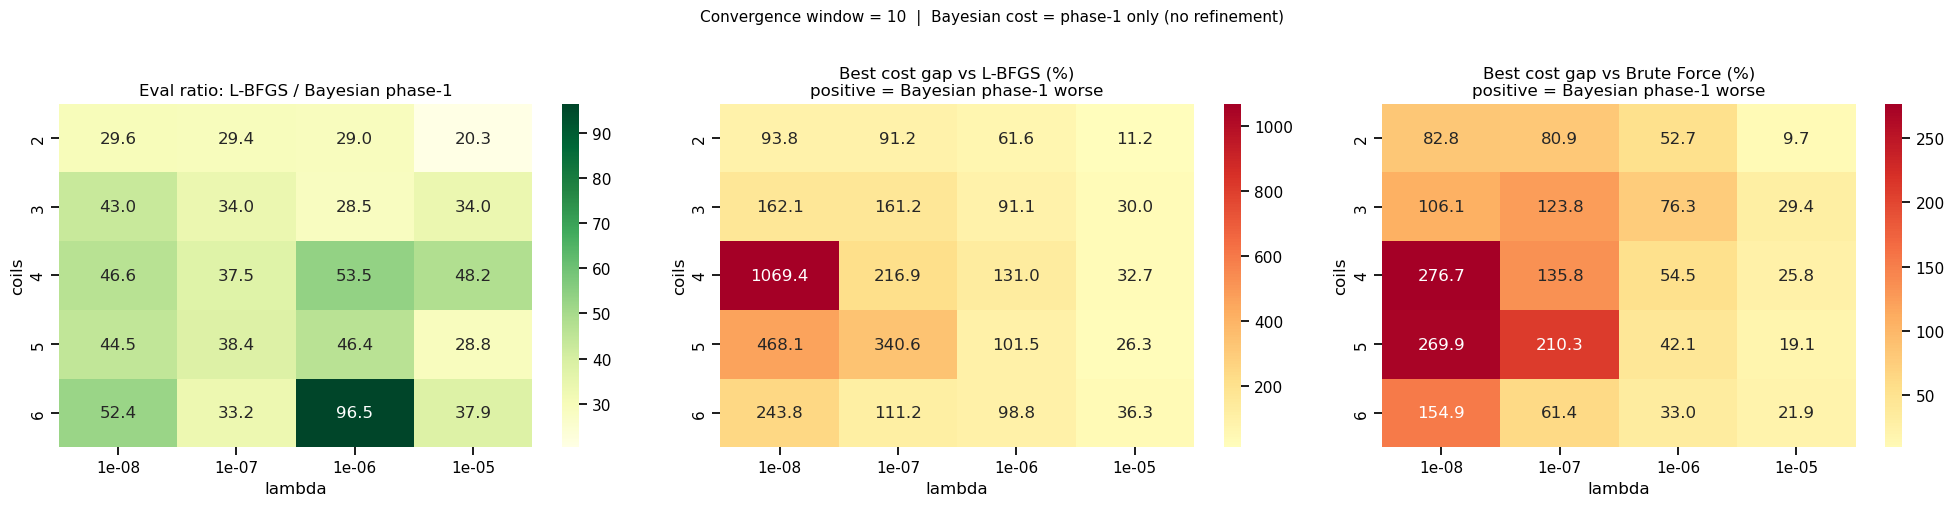

In [ ]:
# Best run per config by Bayesian phase-1 cost at CONV_WINDOW
best = df.sort_values('bayes_cost_w').groupby('config', sort=False).first().reset_index()
best['eval_ratio']     = best['lbfgs_evals_w'] / best['bayes_evals_w']
best['cost_gap_lbfgs'] = (best['bayes_cost_w'] - best['lbfgs_cost_w']) / best['lbfgs_cost_w'] * 100
best['cost_gap_bf']    = (best['bayes_cost_w'] - best['bf_cost'])    / best['bf_cost']    * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Convergence window = {CONV_WINDOW}  |  Bayesian cost = phase-1 only (no refinement)',
             fontsize=11, y=1.01)

for ax, col, title, fmt in [
    (axes[0], 'eval_ratio',
     'Eval ratio: L-BFGS / Bayesian phase-1', '.1f'),
    (axes[1], 'cost_gap_lbfgs',
     'Best cost gap vs L-BFGS (%)\npositive = Bayesian phase-1 worse', '.1f'),
    (axes[2], 'cost_gap_bf',
     'Best cost gap vs Brute Force (%)\npositive = Bayesian phase-1 worse', '.1f'),
]:
    pivot = best.pivot_table(index='coils', columns='lambda', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    cmap   = 'YlGn' if col == 'eval_ratio' else 'RdYlGn_r'
    center = None if col == 'eval_ratio' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, center=center)
    ax.set_title(title)
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

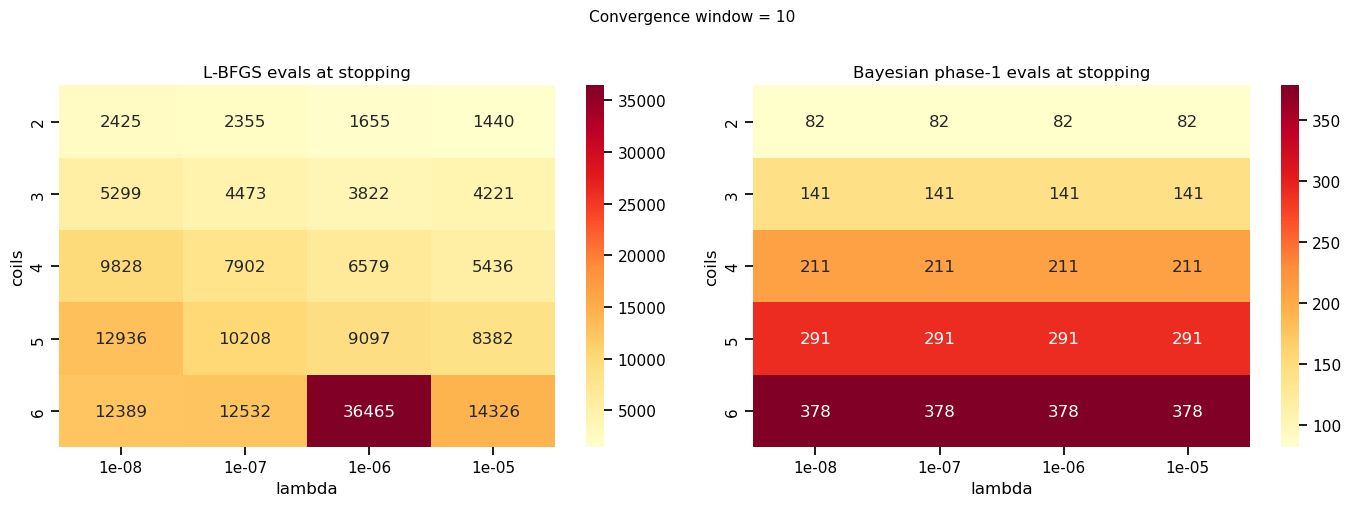

In [ ]:
# Absolute eval counts per method at CONV_WINDOW
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Convergence window = {CONV_WINDOW}', fontsize=11, y=1.01)

lams = sorted(df['lambda'].unique())
for ax, col, title in [
    (axes[0], 'lbfgs_evals_w',  'L-BFGS evals at stopping'),
    (axes[1], 'bayes_evals_w',  'Bayesian phase-1 evals at stopping'),
]:
    sub  = df.sort_values(col).groupby('config', sort=False).first().reset_index()
    pivot = sub.pivot_table(index='coils', columns='lambda', values=col).reindex(lams, axis=1)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

In [ ]:
# Runs per (coils, lambda) — independent of CONV_WINDOW
counts = df.groupby(['coils', 'lambda']).size().reset_index(name='n_runs')
pivot  = counts.pivot(index='coils', columns='lambda', values='n_runs').fillna(0).astype(int)
pivot.columns = [f'{c:.0e}' for c in pivot.columns]
display(pivot)

,1e-08,1e-07,1e-06,1e-05
coils,,,,
2,6,6,6,6
3,6,6,6,6
4,6,6,6,6
5,5,5,6,6
6,5,5,7,7


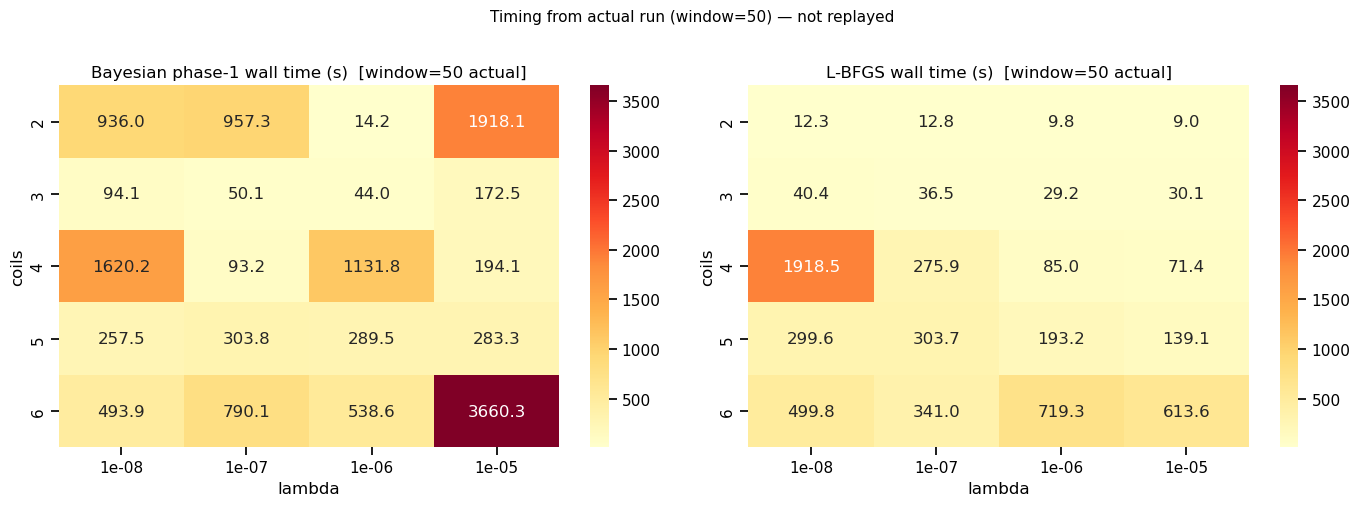

In [ ]:
# Wall-clock time breakdown — reflects the actual run (window=50).
# Timing is not replayed; a smaller window would reduce time proportionally to evals.
timing = df.groupby(['coils', 'lambda']).first().reset_index()
lams   = sorted(timing['lambda'].unique())

pivots = {
    col: timing.pivot_table(index='coils', columns='lambda', values=col).reindex(lams, axis=1)
    for col in ['bayes_phase1_time', 'lbfgs_time']
}

vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

titles = {
    'bayes_phase1_time': 'Bayesian phase-1 wall time (s)  [window=50 actual]',
    'lbfgs_time':        'L-BFGS wall time (s)  [window=50 actual]',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Timing from actual run (window=50) — not replayed', fontsize=11, y=1.01)
for ax, (col, pivot) in zip(axes, pivots.items()):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax)
    ax.set_title(titles[col])
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

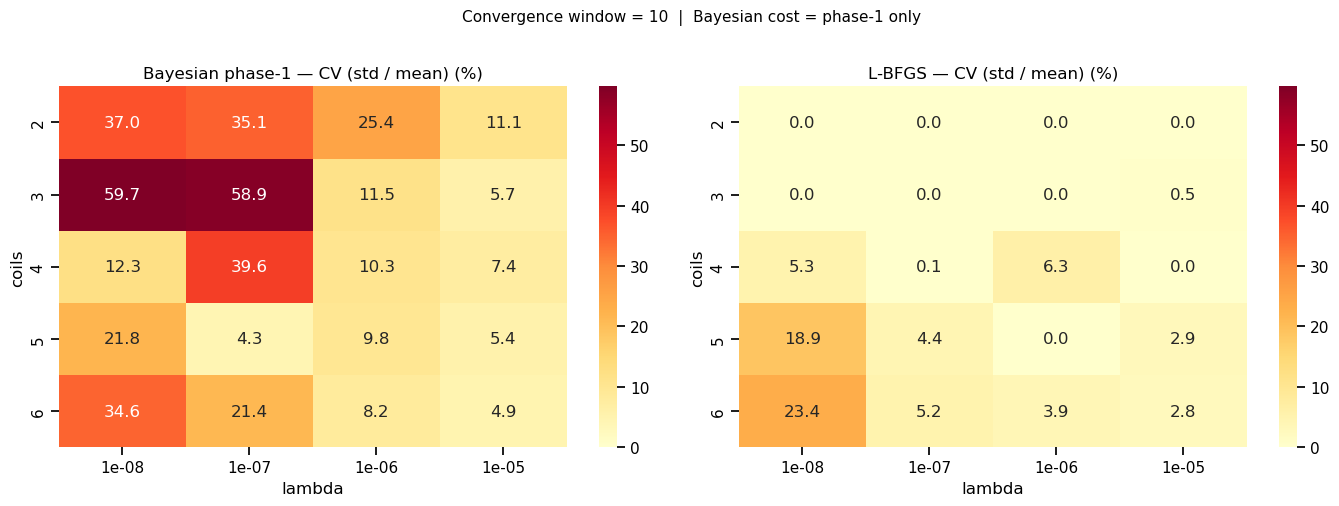

,coils,lambda,n,bayes_mean,bayes_std,bayes_cv,lbfgs_mean,lbfgs_std,lbfgs_cv
0,2,1.000000e-08,6,0.011129,0.004113,36.955017,0.002862,6.084971e-12,2.126068e-07
1,2,1.000000e-07,6,0.013034,0.004571,35.068681,0.002925,7.580455e-13,2.591256e-08
2,2,1.000000e-06,6,0.013855,0.003517,25.381100,0.005956,1.752027e-13,2.941843e-09
3,2,1.000000e-05,6,0.042223,0.004690,11.106749,0.032574,3.597384e-11,1.104384e-07
4,3,1.000000e-08,6,0.000657,0.000392,59.721446,0.000044,5.383168e-11,1.212725e-04
5,3,1.000000e-07,6,0.000812,0.000478,58.898636,0.000091,1.575178e-11,1.730193e-05
6,3,1.000000e-06,6,0.005993,0.000687,11.468326,0.002785,1.143726e-10,4.107104e-06
7,3,1.000000e-05,6,0.043207,0.002446,5.660959,0.030574,1.439488e-04,4.708244e-01
8,4,1.000000e-08,6,0.000117,0.000014,12.330408,0.000009,4.630815e-07,5.323397e+00
9,4,1.000000e-07,6,0.000249,0.000099,39.599434,0.000053,4.827276e-08,9.041369e-02


In [ ]:
# Cost CV across runs (std / mean * 100%) per method at CONV_WINDOW
multi = df.groupby(['coils', 'lambda']).filter(lambda g: len(g) > 1)

if len(multi) == 0:
    print('Only single runs found.')
else:
    stats = multi.groupby(['coils', 'lambda']).agg(
        bayes_mean=('bayes_cost_w', 'mean'), bayes_std=('bayes_cost_w', 'std'),
        lbfgs_mean=('lbfgs_cost_w', 'mean'), lbfgs_std=('lbfgs_cost_w', 'std'),
        n=('bayes_cost_w', 'count'),
    ).reset_index()
    stats['bayes_cv'] = stats['bayes_std'] / stats['bayes_mean'] * 100
    stats['lbfgs_cv'] = stats['lbfgs_std'] / stats['lbfgs_mean'] * 100

    vmin = min(stats['bayes_cv'].min(), stats['lbfgs_cv'].min())
    vmax = max(stats['bayes_cv'].max(), stats['lbfgs_cv'].max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Convergence window = {CONV_WINDOW}  |  Bayesian cost = phase-1 only',
                 fontsize=11, y=1.01)
    for ax, col, title in [
        (axes[0], 'bayes_cv', 'Bayesian phase-1 — CV (std / mean) (%)'),
        (axes[1], 'lbfgs_cv', 'L-BFGS — CV (std / mean) (%)'),
    ]:
        pivot = stats.pivot_table(index='coils', columns='lambda', values=col)
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('lambda')
        ax.set_ylabel('coils')

    plt.tight_layout()
    plt.show()
    display(stats[['coils', 'lambda', 'n',
                   'bayes_mean', 'bayes_std', 'bayes_cv',
                   'lbfgs_mean', 'lbfgs_std', 'lbfgs_cv']])